# Multi-Task Exercise-Boundary Model

## Joint pricing and exercise-decision learning for American put options

**SoftUni Deep Learning Final Project**  
**Author:** Kamen Dimitrov  
**Notebook:** `06_exercise_boundary_analysis.ipynb`

---

American-option pricing is not only a regression problem. The holder must also decide whether immediate exercise dominates continuation. This notebook therefore extends the financially constrained residual model with a second output that classifies the current state as either **exercise** or **continue**.

The notebook compares an exercise-only classifier with a shared-backbone multi-task network. The central question is whether explicitly learning the stopping decision improves classification near the free boundary and also improves pricing accuracy in the same economically difficult region.

# 1. Research objective and hypothesis

The value of an American put option is the higher of:

* the value received from exercising immediately; and
* the value of keeping the option alive.

This is written as:

$$
V_A(S_t,t) = \max\left(I(S_t),C(S_t,t)\right).
$$

The immediate exercise value is:

$$
I(S_t) = \max(K-S_t,0).
$$

The continuation value is:

$$
C(S_t,t) = \mathbb{E}^{\mathbb{Q}}
\left[e^{-r\Delta t}
V_A(S_{t+\Delta t},t+\Delta t)
\mid S_t
\right].
$$

The exercise decision is represented by:

$$
Y_{\text{exercise}} = \mathbb{1}
\left[
I(S_t)\geq C(S_t,t)
\right].
$$

Where:

* $V_A(S_t,t)$ is the value of the American put at time $t$;
* $S_t$ is the underlying asset price at time $t$;
* $S_{t+\Delta t}$ is the asset price at the next time step;
* $K$ is the option strike price;
* $I(S_t)$ is the value received from exercising immediately;
* $C(S_t,t)$ is the value of continuing to hold the option;
* $r$ is the continuously compounded risk-free interest rate;
* $\Delta t$ is the length of one time step;
* $\mathbb{E}^{\mathbb{Q}}[\cdot]$ is the expected value under the risk-neutral probability measure;
* $e^{-r\Delta t}$ discounts the future option value back to time $t$;
* $\mathbb{1}[\cdot]$ is an indicator function equal to 1 when the condition is true and 0 otherwise;
* $Y_{\text{exercise}}=1$ means exercise now, while $Y_{\text{exercise}}=0$ means continue holding the option.

The multi-task model jointly estimates:

1. the normalized residual above the financial floor; and
2. the probability that immediate exercise is optimal.

This notebook evaluates **H4 — Multi-task exercise learning**:

> A network jointly trained on pricing and exercise classification will estimate the exercise boundary more accurately than separate price-only and classification baselines.


In [1]:
from pathlib import Path
import json
import sys
import time
from tqdm.auto import tqdm
import shutil

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torchinfo import summary

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.torch_datasets import (
    FEATURE_COLUMNS,
    LoaderConfig,
    MultiTaskAmericanOptionDataset,
    create_multitask_loader,
    load_feature_scaler,
    read_parquet_components,
)

from src.data.json_export import _write_export_json

from src.evaluation.exercise_boundary_support import (
    boundary_decision_diagnostics,
    build_boundary_slice,
)
from src.evaluation.inference_benchmark import benchmark_forward_pass
from src.training.artifact_management import (
    backfill_manifest_dependencies,
    canonicalize_json_value,
    inspect_training_artifacts,
    write_training_manifest,
)

from src.evaluation.classification_metrics import (
    binary_classification_metrics,
    calibration_frame,
    choose_f1_threshold,
    confusion_matrix_frame,
)

from src.evaluation.exercise_boundary import (
    H4Decision,
    boundary_band_metrics,
    boundary_location_error,
    boundary_monotonicity_report,
    extract_label_boundary,
    extract_probability_boundary,
    validate_exercise_labels,
)

from src.evaluation.regression_metrics import regression_metrics

from src.models.multitask_pricer import (
    ExerciseClassifierConfig,
    ExerciseClassifierMLP,
    MultiTaskAmericanPutMLP,
    MultiTaskMLPConfig,
)

from src.models.premium_pricer import PremiumAmericanPutMLP, PremiumMLPConfig
from src.training.checkpointing import load_checkpoint, save_json
from src.training.dependency_fingerprints import (
    build_training_dependencies,
    calculate_file_sha256,
)
from src.training.loops import predict_regression_model, set_global_seed
from src.training.multitask_losses import (
    MultiTaskLossConfig,
    MultiTaskPricingLoss,
    calculate_positive_class_weight,
)

from src.training.multitask_loops import (
    MultiTaskTrainingConfig,
    fit_exercise_classifier,
    fit_multitask_model,
    predict_exercise_classifier,
    predict_multitask_model,
)

from src.pricing.black_scholes import black_scholes_put_price
from src.pricing.binomial_tree import crr_option_diagnostics

In [2]:
DATA_DIR = PROJECT_ROOT / "data" / "generated"
MANIFEST_DIR = PROJECT_ROOT / "data" / "manifests"
DIRECT_ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "direct_mlp"
PREMIUM_ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "premium_models"
MULTITASK_ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "multitask_model"
MULTITASK_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

CORE_PATHS = [
    DATA_DIR / "american_put_core.parquet",
    DATA_DIR / "american_put_boundary.parquet",
]
OOD_PATHS = {
    "high_volatility": DATA_DIR / "american_put_ood_high_volatility.parquet",
    "extreme_moneyness": DATA_DIR / "american_put_ood_extreme_moneyness.parquet",
    "long_maturity": DATA_DIR / "american_put_ood_long_maturity.parquet",
    "rate_dividend": DATA_DIR / "american_put_ood_rate_dividend.parquet",
}
PRODUCTION_MANIFEST_PATH = MANIFEST_DIR / "production_dataset_manifest.json"
SCALER_PATH = DIRECT_ARTIFACT_DIR / "feature_scaler.joblib"
PREMIUM_SUMMARY_PATH = PREMIUM_ARTIFACT_DIR / "evaluation_summary.json"

# Set to True only for the first run after introducing dependency
# fingerprints to an existing training package. It updates metadata
# only and does not retrain or modify model weights.
BACKFILL_LEGACY_DEPENDENCIES = False

#This is a very important config setting!
#Keep False if model has been trained already
#Set to True if you desire to train the model
FORCE_TRAIN = False

SEED = 42
FAST_DEV_MODE = False
TRAINING_PROFILE = "fast_dev" if FAST_DEV_MODE else "full"
TRAIN_LIMIT = 150_000 if FAST_DEV_MODE else None
VALIDATION_LIMIT = 35_000 if FAST_DEV_MODE else None
TEST_LIMIT = 35_000 if FAST_DEV_MODE else None

set_global_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cpu


# 2. Dependency and data validation

Notebook 06 reuses the DVC-managed production data, the Notebook 04 feature scaler, and the selected constrained price model from Notebook 05. The files are restored from the project R2 storage with `dvc pull`; they are not regenerated or refitted here.

`FORCE_TRAIN = False` reuses compatible classifier and multi-task packages. Before loading them, the notebook verifies fingerprints for the production manifest, scaler, feature order, Notebook 05 evaluation summary, and selected Notebook 05 checkpoint. A changed dependency makes the saved package incompatible and triggers training.

`BACKFILL_LEGACY_DEPENDENCIES` is a one-time migration switch for artifacts created before these fingerprints were recorded. It updates metadata only and should be returned to `False` after one successful clean run.


In [3]:
static_required_paths = [
    *CORE_PATHS,
    *OOD_PATHS.values(),
    PRODUCTION_MANIFEST_PATH,
    SCALER_PATH,
    PREMIUM_SUMMARY_PATH,
]
missing = [path for path in static_required_paths if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Notebook 06 prerequisites are missing:\n"
        + "\n".join(f"- {path}" for path in missing)
    )

with PREMIUM_SUMMARY_PATH.open("r", encoding="utf-8") as file:
    premium_summary = json.load(file)

BEST_FLOOR_CANDIDATE = premium_summary["best_floor_candidate"]
PREMIUM_CHECKPOINT_PATH = (
    PREMIUM_ARTIFACT_DIR / f"best_{BEST_FLOOR_CANDIDATE}.pt"
)
if not PREMIUM_CHECKPOINT_PATH.is_file():
    raise FileNotFoundError(PREMIUM_CHECKPOINT_PATH)

current_external_dependencies = build_training_dependencies(
    project_root=PROJECT_ROOT,
    feature_scaler_path=SCALER_PATH,
    production_manifest_path=PRODUCTION_MANIFEST_PATH,
    feature_columns=FEATURE_COLUMNS,
)
current_external_dependencies.update(
    {
        "premium_summary": {
            "path": PREMIUM_SUMMARY_PATH.relative_to(
                PROJECT_ROOT
            ).as_posix(),
            "sha256": calculate_file_sha256(
                PREMIUM_SUMMARY_PATH
            ),
        },
        "premium_checkpoint": {
            "path": PREMIUM_CHECKPOINT_PATH.relative_to(
                PROJECT_ROOT
            ).as_posix(),
            "sha256": calculate_file_sha256(
                PREMIUM_CHECKPOINT_PATH
            ),
        },
        "premium_candidate": BEST_FLOOR_CANDIDATE,
    }
)

MODEL_COLUMNS = [
    "sample_id", "component", "split", *FEATURE_COLUMNS,
    "moneyness", "strike", "intrinsic_value", "continuation_value",
    "normalized_european_price", "normalized_american_price",
    "boundary_distance_normalized", "exercise_now",
]

train_frame = read_parquet_components(
    CORE_PATHS, columns=MODEL_COLUMNS, split="train", row_limit=TRAIN_LIMIT
)
validation_frame = read_parquet_components(
    CORE_PATHS, columns=MODEL_COLUMNS, split="validation", row_limit=VALIDATION_LIMIT
)
test_frame = read_parquet_components(
    CORE_PATHS, columns=MODEL_COLUMNS, split="test", row_limit=TEST_LIMIT
)

for frame in (train_frame, validation_frame, test_frame):
    frame["normalized_intrinsic_value"] = (
        frame["intrinsic_value"] / frame["strike"]
    )
    frame["normalized_financial_floor"] = np.maximum(
        frame["normalized_european_price"],
        frame["normalized_intrinsic_value"],
    )
    frame["normalized_floor_residual"] = (
        frame["normalized_american_price"]
        - frame["normalized_financial_floor"]
    ).clip(lower=0.0)

    # Keep direction and distance separate. The production column stores the
    # absolute distance; the signed margin identifies the exercise side.
    frame["signed_boundary_margin"] = (
        frame["intrinsic_value"]
        - frame["continuation_value"]
    ) / frame["strike"]
    frame["boundary_distance_normalized"] = (
        frame["signed_boundary_margin"].abs()
    )

label_validation = pd.DataFrame(
    {
        split_name: validate_exercise_labels(frame)
        for split_name, frame in {
            "train": train_frame,
            "validation": validation_frame,
            "test": test_frame,
        }.items()
    }
).T
label_validation

,observations,mismatches,mismatch_rate
train,874512.0,0.0,0.0
validation,187677.0,0.0,0.0
test,187811.0,0.0,0.0


# 3. Exercise-region representation

A raw accuracy score can be misleading when immediate exercise is uncommon. The experiment therefore reports class balance across the major financial dimensions and uses class-weighted binary cross entropy fitted only on the training split.

In [4]:
class_balance = pd.DataFrame(
    {
        "observations": [len(train_frame), len(validation_frame), len(test_frame)],
        "exercise_rate": [
            train_frame["exercise_now"].mean(),
            validation_frame["exercise_now"].mean(),
            test_frame["exercise_now"].mean(),
        ],
    },
    index=["train", "validation", "test"],
)
class_balance

,observations,exercise_rate
train,874512,0.239707
validation,187677,0.239523
test,187811,0.240454


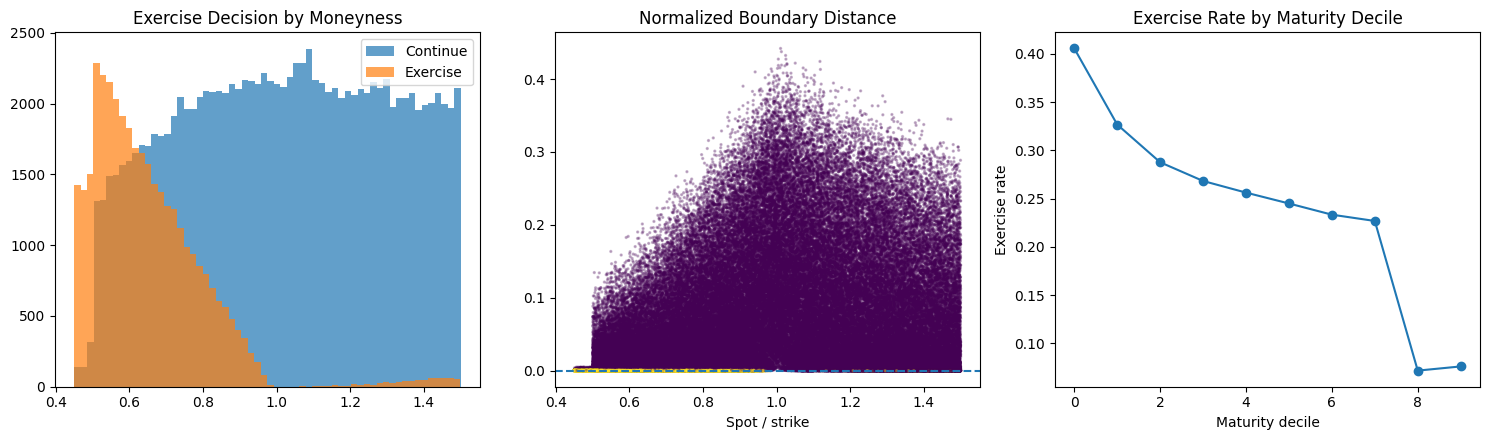

In [5]:
analysis_sample = train_frame.sample(
    min(150_000, len(train_frame)),
    random_state=SEED,
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
axes[0].hist(
    analysis_sample.loc[~analysis_sample["exercise_now"], "moneyness"],
    bins=60,
    alpha=0.7,
    label="Continue",
)
axes[0].hist(
    analysis_sample.loc[analysis_sample["exercise_now"], "moneyness"],
    bins=60,
    alpha=0.7,
    label="Exercise",
)
axes[0].set_title("Exercise Decision by Moneyness")
axes[0].legend()

axes[1].scatter(
    analysis_sample["moneyness"],
    analysis_sample["boundary_distance_normalized"],
    c=analysis_sample["exercise_now"].astype(int),
    s=2,
    alpha=0.25,
)
axes[1].axhline(0.0, linestyle="--")
axes[1].set_title("Normalized Boundary Distance")
axes[1].set_xlabel("Spot / strike")

exercise_by_maturity = (
    analysis_sample.assign(
        maturity_bucket=pd.qcut(
            analysis_sample["time_to_maturity"],
            q=10,
            duplicates="drop",
        )
    )
    .groupby("maturity_bucket", observed=True)["exercise_now"]
    .mean()
)
axes[2].plot(range(len(exercise_by_maturity)), exercise_by_maturity.values, marker="o")
axes[2].set_title("Exercise Rate by Maturity Decile")
axes[2].set_xlabel("Maturity decile")
axes[2].set_ylabel("Exercise rate")
plt.tight_layout()
plt.show()

# 4. PyTorch input pipeline

The multi-task dataset returns one shared feature tensor together with:

- the normalized floor-residual target;
- the binary exercise target;
- normalized European, intrinsic, and American values;
- the source row identifier.

The feature scaler fitted in Notebook 04 is reused unchanged.

In [6]:
feature_scaler = load_feature_scaler(SCALER_PATH)
LOADER_CONFIG = LoaderConfig(
    batch_size=1024,
    num_workers=0,
    pin_memory=True,
    seed=SEED,
)


def make_multitask_loader(frame, *, shuffle=False, drop_last=False):
    dataset = MultiTaskAmericanOptionDataset(
        frame,
        scaler=feature_scaler,
        residual_target_column="normalized_floor_residual",
    )
    loader = create_multitask_loader(
        dataset,
        config=LOADER_CONFIG,
        shuffle=shuffle,
        drop_last=drop_last,
    )
    return dataset, loader


_, train_loader = make_multitask_loader(train_frame, shuffle=True, drop_last=True)
_, validation_loader = make_multitask_loader(validation_frame, shuffle=False)
_, test_loader = make_multitask_loader(test_frame, shuffle=False)

batch = next(iter(train_loader))
{
    key: tuple(value.shape) if isinstance(value, torch.Tensor) else type(value).__name__
    for key, value in batch.items()
}

C:\Users\kamen.dimitrov\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


{'features': (1024, 5),
 'residual_target': (1024, 1),
 'exercise_target': (1024, 1),
 'normalized_european': (1024, 1),
 'normalized_intrinsic': (1024, 1),
 'normalized_american': (1024, 1),
 'row_id': (1024,)}

# 5. Exercise-only classifier baseline

Before joint learning, a separate classifier is trained using the same five pricing inputs. This baseline determines whether the stopping decision is learnable independently of the price objective.

The positive-class weight is estimated only from the training split:

$$
w_+=\frac{N_{continue}}{N_{exercise}}.
$$

**Execution control.** `FORCE_TRAIN = True` retrains both the exercise-only classifier and the multi-task candidates. After a successful run, set it to `False`; each stage is checked and loaded independently, while any missing or incomplete stage is retrained automatically.


In [7]:
positive_class_weight = calculate_positive_class_weight(
    train_frame["exercise_now"]
)
CLASSIFIER_TRAINING_CONFIG = MultiTaskTrainingConfig(
    epochs=100,
    learning_rate=1e-3,
    weight_decay=1e-5,
    early_stopping_patience=10,
    scheduler_patience=4,
    mixed_precision=True,
    seed=SEED,
)
CLASSIFIER_MODEL_CONFIG = ExerciseClassifierConfig(
    input_features=len(FEATURE_COLUMNS),
    hidden_sizes=(128, 128, 64, 32),
    batch_norm_after=(0, 1),
)

CLASSIFIER_CHECKPOINT_PATH = (
    MULTITASK_ARTIFACT_DIR / "best_exercise_classifier.pt"
)
CLASSIFIER_HISTORY_PATH = (
    MULTITASK_ARTIFACT_DIR / "exercise_classifier_history.csv"
)
CLASSIFIER_CONFIG_PATH = (
    MULTITASK_ARTIFACT_DIR / "exercise_classifier_training_config.json"
)
CLASSIFIER_MODEL_CONFIG_PATH = (
    MULTITASK_ARTIFACT_DIR / "exercise_classifier_model_config.json"
)
CLASSIFIER_MANIFEST_PATH = (
    MULTITASK_ARTIFACT_DIR / "exercise_classifier_complete.json"
)

classifier_dependencies = {
    **current_external_dependencies,
    "classifier_model_config": CLASSIFIER_MODEL_CONFIG.to_dict(),
    "positive_class_weight": float(positive_class_weight),
}

# Legacy classifier checkpoints did not include architecture metadata.
# Backfill a separate immutable config file and the dependency manifest only.
if (
    BACKFILL_LEGACY_DEPENDENCIES
    and not FORCE_TRAIN
    and CLASSIFIER_MANIFEST_PATH.is_file()
    and CLASSIFIER_CHECKPOINT_PATH.is_file()
    and not CLASSIFIER_MODEL_CONFIG_PATH.is_file()
):
    save_json(
        CLASSIFIER_MODEL_CONFIG.to_dict(),
        CLASSIFIER_MODEL_CONFIG_PATH,
    )

if backfill_manifest_dependencies(
    CLASSIFIER_MANIFEST_PATH,
    classifier_dependencies,
    enabled=BACKFILL_LEGACY_DEPENDENCIES,
    force_train=FORCE_TRAIN,
):
    print("Added dependency fingerprints to the classifier manifest.")

classifier_outputs_available, classifier_availability_reason = (
    inspect_training_artifacts(
        CLASSIFIER_MANIFEST_PATH,
        [
            CLASSIFIER_CHECKPOINT_PATH,
            CLASSIFIER_HISTORY_PATH,
            CLASSIFIER_CONFIG_PATH,
            CLASSIFIER_MODEL_CONFIG_PATH,
        ],
        expected_notebook="06_exercise_classifier",
        expected_profile=TRAINING_PROFILE,
        expected_dependencies=classifier_dependencies,
    )
)
RUN_CLASSIFIER_TRAINING = (
    FORCE_TRAIN or not classifier_outputs_available
)

print(f"Force training:               {FORCE_TRAIN}")
print(f"Classifier outputs available: {classifier_outputs_available}")
print(
    "Classifier decision:         "
    f"{'train' if RUN_CLASSIFIER_TRAINING else 'load'}"
)
print(f"Classifier artifact check:    {classifier_availability_reason}")

if RUN_CLASSIFIER_TRAINING:
    exercise_classifier = ExerciseClassifierMLP(
        CLASSIFIER_MODEL_CONFIG
    ).to(DEVICE)

    CLASSIFIER_MANIFEST_PATH.unlink(missing_ok=True)
    classifier_started = time.perf_counter()

    classifier_history = fit_exercise_classifier(
        exercise_classifier,
        train_loader,
        validation_loader,
        positive_class_weight=positive_class_weight,
        config=CLASSIFIER_TRAINING_CONFIG,
        device=DEVICE,
        checkpoint_path=CLASSIFIER_CHECKPOINT_PATH,
    )
    classifier_runtime_seconds = time.perf_counter() - classifier_started

    classifier_history.to_csv(
        CLASSIFIER_HISTORY_PATH,
        index=False,
    )
    save_json(
        CLASSIFIER_TRAINING_CONFIG.to_dict(),
        CLASSIFIER_CONFIG_PATH,
    )
    save_json(
        CLASSIFIER_MODEL_CONFIG.to_dict(),
        CLASSIFIER_MODEL_CONFIG_PATH,
    )

    classifier_checkpoint = load_checkpoint(
        CLASSIFIER_CHECKPOINT_PATH,
        map_location="cpu",
    )
    epochs_completed = int(classifier_history["epoch"].max())

    write_training_manifest(
        CLASSIFIER_MANIFEST_PATH,
        {
            "status": "complete",
            "notebook": "06_exercise_classifier",
            "training_profile": TRAINING_PROFILE,
            "dependencies": canonicalize_json_value(
                classifier_dependencies
            ),
            "requested_epochs": int(CLASSIFIER_TRAINING_CONFIG.epochs),
            "epochs_completed": epochs_completed,
            "best_epoch": int(classifier_checkpoint["epoch"]),
            "early_stopped": (
                epochs_completed
                < int(CLASSIFIER_TRAINING_CONFIG.epochs)
            ),
            "best_validation_loss": float(
                classifier_checkpoint["validation_loss"]
            ),
            "training_runtime_seconds": float(
                classifier_runtime_seconds
            ),
            "checkpoint": CLASSIFIER_CHECKPOINT_PATH.name,
            "history": CLASSIFIER_HISTORY_PATH.name,
            "model_config": CLASSIFIER_MODEL_CONFIG_PATH.name,
        },
    )
else:
    classifier_history = pd.read_csv(CLASSIFIER_HISTORY_PATH)
    classifier_checkpoint = load_checkpoint(
        CLASSIFIER_CHECKPOINT_PATH,
        map_location=DEVICE,
    )

    raw_classifier_config = json.loads(
        CLASSIFIER_MODEL_CONFIG_PATH.read_text(
            encoding="utf-8"
        )
    )
    saved_classifier_config = ExerciseClassifierConfig(
        input_features=int(
            raw_classifier_config["input_features"]
        ),
        hidden_sizes=tuple(
            raw_classifier_config["hidden_sizes"]
        ),
        batch_norm_after=tuple(
            raw_classifier_config["batch_norm_after"]
        ),
    )
    exercise_classifier = ExerciseClassifierMLP(
        saved_classifier_config
    ).to(DEVICE)
    exercise_classifier.load_state_dict(
        classifier_checkpoint["model_state_dict"]
    )
    exercise_classifier.eval()

classifier_history.tail()

Force training:               False
Classifier outputs available: True
Classifier decision:         load
Classifier artifact check:    complete compatible package found


,epoch,train_loss,validation_loss,train_accuracy,validation_accuracy,learning_rate,epoch_seconds
68,69.0,0.036511,0.019719,0.988839,0.995162,0.000031,19.135182
69,70.0,0.036294,0.019971,0.988677,0.993340,0.000031,18.997761
70,71.0,0.036568,0.020427,0.988697,0.992551,0.000031,18.758493
71,72.0,0.037615,0.020620,0.988351,0.991954,0.000031,18.951831
72,73.0,0.036790,0.019624,0.988577,0.995013,0.000016,18.884017


In [8]:
classifier_validation_predictions = predict_exercise_classifier(
    exercise_classifier,
    validation_loader,
    device=DEVICE,
)
classifier_validation = validation_frame[[
    "sample_id", "exercise_now", "boundary_distance_normalized"
]].merge(
    classifier_validation_predictions,
    on="sample_id",
    validate="one_to_one",
)
classifier_threshold_result = choose_f1_threshold(
    classifier_validation["exercise_now"],
    classifier_validation["exercise_probability"],
)
CLASSIFIER_THRESHOLD = classifier_threshold_result["threshold"]
classifier_validation_metrics = binary_classification_metrics(
    classifier_validation["exercise_now"],
    classifier_validation["exercise_probability"],
    threshold=CLASSIFIER_THRESHOLD,
)
pd.Series(classifier_validation_metrics, name="classifier validation")

observations         187677.000000
positive_rate             0.239523
threshold                 0.670000
accuracy                  0.998465
balanced_accuracy         0.998046
precision                 0.996355
recall                    0.997242
f1                        0.996798
brier_score               0.003662
roc_auc                   0.999984
pr_auc                    0.999951
Name: classifier validation, dtype: float64

# 6. Multi-task architecture and loss-weight selection

The multi-task model uses one shared backbone and two output heads:

```text
Input features
→ Shared representation
   ├── non-negative price-residual prediction
   └── exercise probability
```

The training loss combines the two objectives:

$$
\mathcal{L} = \mathcal{L}*{price}
+
\lambda\mathcal{L}*{exercise}.
$$

A higher value of $\lambda$ gives the exercise decision more influence during training.

Three predefined values are tested: $0.1$, $0.5$, and $1.0$. They are first compared using exercise F1 within the boundary region. Any candidate within 0.001 of the best F1 remains eligible, and the final choice is the eligible model with the lowest validation pricing MAE.

This avoids selecting a model because of a negligible F1 difference while ignoring a meaningful pricing improvement.

In [9]:
LAMBDA_CANDIDATES = (0.1, 0.5, 1.0)

MULTITASK_TRAINING_CONFIG = MultiTaskTrainingConfig(
    epochs=100,
    learning_rate=1e-3,
    weight_decay=1e-5,
    early_stopping_patience=10,
    scheduler_patience=4,
    mixed_precision=True,
    seed=SEED,
)

MODEL_CONFIG = MultiTaskMLPConfig(
    input_features=len(FEATURE_COLUMNS),
    shared_hidden_sizes=(128, 128, 64),
    batch_norm_after=(0, 1),
    regression_head_sizes=(32,),
    classification_head_sizes=(32,),
    residual_softplus=True,
)

MULTITASK_MANIFEST_PATH = (
    MULTITASK_ARTIFACT_DIR / "multitask_training_complete.json"
)
MULTITASK_CONFIG_PATH = (
    MULTITASK_ARTIFACT_DIR / "multitask_training_config.json"
)
MULTITASK_MODEL_CONFIG_PATH = (
    MULTITASK_ARTIFACT_DIR / "multitask_model_config.json"
)
MULTITASK_CANDIDATE_SUMMARY_PATH = (
    MULTITASK_ARTIFACT_DIR / "candidate_training_summary.csv"
)

candidate_names = [
    f"lambda_{exercise_lambda:g}".replace(".", "p")
    for exercise_lambda in LAMBDA_CANDIDATES
]
candidate_checkpoint_paths = {
    name: MULTITASK_ARTIFACT_DIR / f"best_multitask_{name}.pt"
    for name in candidate_names
}
candidate_history_paths = {
    name: MULTITASK_ARTIFACT_DIR / f"training_history_{name}.csv"
    for name in candidate_names
}

multitask_dependencies = {
    **current_external_dependencies,
    "multitask_model_config": MODEL_CONFIG.to_dict(),
    "lambda_candidates": list(LAMBDA_CANDIDATES),
    "positive_class_weight": float(positive_class_weight),
}

if backfill_manifest_dependencies(
    MULTITASK_MANIFEST_PATH,
    multitask_dependencies,
    enabled=BACKFILL_LEGACY_DEPENDENCIES,
    force_train=FORCE_TRAIN,
):
    print("Added dependency fingerprints to the multi-task manifest.")

multitask_outputs_available, multitask_availability_reason = (
    inspect_training_artifacts(
        MULTITASK_MANIFEST_PATH,
        [
            MULTITASK_CONFIG_PATH,
            MULTITASK_MODEL_CONFIG_PATH,
            MULTITASK_CANDIDATE_SUMMARY_PATH,
            *candidate_checkpoint_paths.values(),
            *candidate_history_paths.values(),
        ],
        expected_notebook="06_multitask_model",
        expected_profile=TRAINING_PROFILE,
        expected_dependencies=multitask_dependencies,
    )
)
RUN_MULTITASK_TRAINING = (
    FORCE_TRAIN or not multitask_outputs_available
)

print(f"Multi-task outputs available: {multitask_outputs_available}")
print(
    "Multi-task decision:         "
    f"{'train' if RUN_MULTITASK_TRAINING else 'load'}"
)
print(f"Multi-task artifact check:    {multitask_availability_reason}")

candidate_results = {}
if RUN_MULTITASK_TRAINING:
    MULTITASK_MANIFEST_PATH.unlink(missing_ok=True)

candidate_progress = tqdm(
    LAMBDA_CANDIDATES,
    desc=(
        "Training multi-task candidates"
        if RUN_MULTITASK_TRAINING
        else "Loading multi-task candidates"
    ),
    unit="model",
)
multitask_started = (
    time.perf_counter()
    if RUN_MULTITASK_TRAINING
    else None
)

for requested_lambda in candidate_progress:
    candidate_name = (
        f"lambda_{requested_lambda:g}".replace(".", "p")
    )
    checkpoint_path = candidate_checkpoint_paths[candidate_name]
    history_path = candidate_history_paths[candidate_name]

    candidate_progress.set_description(
        (
            f"Training {candidate_name}"
            if RUN_MULTITASK_TRAINING
            else f"Loading {candidate_name}"
        )
    )

    if RUN_MULTITASK_TRAINING:
        model = MultiTaskAmericanPutMLP(
            MODEL_CONFIG
        ).to(DEVICE)

        print(
            f"\n{'=' * 72}\n"
            f"Training multi-task candidate: {candidate_name}\n"
            f"Exercise-loss weight: {requested_lambda}\n"
            f"Device: {DEVICE}\n"
            f"{'=' * 72}",
            flush=True,
        )

        loss_config = MultiTaskLossConfig(
            exercise_lambda=requested_lambda
        )
        loss_fn = MultiTaskPricingLoss(
            config=loss_config,
            positive_class_weight=positive_class_weight,
        ).to(DEVICE)

        history = fit_multitask_model(
            model,
            train_loader,
            validation_loader,
            loss_fn=loss_fn,
            config=MULTITASK_TRAINING_CONFIG,
            device=DEVICE,
            checkpoint_path=checkpoint_path,
            model_config=MODEL_CONFIG.to_dict(),
        )
        history.to_csv(history_path, index=False)
        checkpoint = load_checkpoint(
            checkpoint_path,
            map_location=DEVICE,
        )
    else:
        history = pd.read_csv(history_path)
        checkpoint = load_checkpoint(
            checkpoint_path,
            map_location=DEVICE,
        )

        raw_model_config = checkpoint.get("model_config")
        if not isinstance(raw_model_config, dict):
            raise ValueError(
                f"Checkpoint {checkpoint_path.name} has no model_config."
            )

        saved_model_config = MultiTaskMLPConfig(
            input_features=int(
                raw_model_config["input_features"]
            ),
            shared_hidden_sizes=tuple(
                raw_model_config["shared_hidden_sizes"]
            ),
            batch_norm_after=tuple(
                raw_model_config["batch_norm_after"]
            ),
            regression_head_sizes=tuple(
                raw_model_config["regression_head_sizes"]
            ),
            classification_head_sizes=tuple(
                raw_model_config["classification_head_sizes"]
            ),
            residual_softplus=bool(
                raw_model_config["residual_softplus"]
            ),
        )
        model = MultiTaskAmericanPutMLP(
            saved_model_config
        ).to(DEVICE)
        model.load_state_dict(
            checkpoint["model_state_dict"]
        )
        model.eval()

    saved_loss_config = checkpoint.get("loss_config", {})
    exercise_lambda = float(
        saved_loss_config.get(
            "exercise_lambda",
            requested_lambda,
        )
    )

    validation_predictions = predict_multitask_model(
        model,
        validation_loader,
        device=DEVICE,
    )

    validation_result = validation_frame[
        [
            "sample_id",
            "exercise_now",
            "boundary_distance_normalized",
            "normalized_american_price",
        ]
    ].merge(
        validation_predictions,
        on="sample_id",
        validate="one_to_one",
    )

    threshold_result = choose_f1_threshold(
        validation_result["exercise_now"],
        validation_result["exercise_probability"],
    )
    threshold = threshold_result["threshold"]

    boundary_metrics = boundary_band_metrics(
        validation_result,
        probability_column="exercise_probability",
        bands=(0.01,),
        threshold=threshold,
        actual_price_column="normalized_american_price",
        predicted_price_column=(
            "predicted_normalized_american_price"
        ),
    ).iloc[0]

    candidate_results[candidate_name] = {
        "exercise_lambda": exercise_lambda,
        "model": model,
        "checkpoint": checkpoint,
        "checkpoint_path": checkpoint_path,
        "threshold": threshold,
        "boundary_f1": float(boundary_metrics["f1"]),
        "boundary_price_mae": float(
            boundary_metrics["price_mae"]
        ),
        "history": history,
    }

    candidate_progress.set_postfix(
        boundary_f1=f"{boundary_metrics['f1']:.4f}",
        price_mae=f"{boundary_metrics['price_mae']:.6f}",
    )

candidate_summary = pd.DataFrame(
    {
        name: {
            "exercise_lambda": result["exercise_lambda"],
            "threshold": result["threshold"],
            "boundary_f1": result["boundary_f1"],
            "boundary_price_mae": (
                result["boundary_price_mae"]
            ),
        }
        for name, result in candidate_results.items()
    }
).T.sort_values(
    ["boundary_f1", "boundary_price_mae"],
    ascending=[False, True],
)

if RUN_MULTITASK_TRAINING:
    multitask_runtime_seconds = (
        time.perf_counter() - multitask_started
    )
    candidate_summary.to_csv(
        MULTITASK_CANDIDATE_SUMMARY_PATH
    )
    save_json(
        MULTITASK_TRAINING_CONFIG.to_dict(),
        MULTITASK_CONFIG_PATH,
    )
    save_json(
        MODEL_CONFIG.to_dict(),
        MULTITASK_MODEL_CONFIG_PATH,
    )

    write_training_manifest(
        MULTITASK_MANIFEST_PATH,
        {
            "status": "complete",
            "notebook": "06_multitask_model",
            "training_profile": TRAINING_PROFILE,
            "dependencies": canonicalize_json_value(
                multitask_dependencies
            ),
            "requested_epochs_per_candidate": int(
                MULTITASK_TRAINING_CONFIG.epochs
            ),
            "candidate_count": len(candidate_results),
            "training_runtime_seconds": float(
                multitask_runtime_seconds
            ),
            "candidates": {
                name: {
                    "exercise_lambda": float(
                        result["exercise_lambda"]
                    ),
                    "threshold": float(result["threshold"]),
                    "boundary_f1": float(result["boundary_f1"]),
                    "boundary_price_mae": float(
                        result["boundary_price_mae"]
                    ),
                    "checkpoint": result[
                        "checkpoint_path"
                    ].name,
                    "history": candidate_history_paths[name].name,
                }
                for name, result in candidate_results.items()
            },
        },
    )

candidate_summary

Multi-task outputs available: True
Multi-task decision:         load
Multi-task artifact check:    complete compatible package found


Loading multi-task candidates:   0%|          | 0/3 [00:00<?, ?model/s]

,exercise_lambda,threshold,boundary_f1,boundary_price_mae
lambda_0p1,0.1,0.685,0.996772,0.000154
lambda_1,1.0,0.675,0.996030,0.000122
lambda_0p5,0.5,0.665,0.994872,0.000137


In [10]:
F1_SELECTION_TOLERANCE = 0.001

best_validation_f1 = float(
    candidate_summary["boundary_f1"].max()
)
eligible_candidates = candidate_summary.loc[
    candidate_summary["boundary_f1"]
    >= best_validation_f1 - F1_SELECTION_TOLERANCE
].sort_values(
    ["boundary_price_mae", "boundary_f1"],
    ascending=[True, False],
)

best_candidate_name = eligible_candidates.index[0]
best_candidate = candidate_results[best_candidate_name]
best_multitask_model = best_candidate["model"]
MULTITASK_THRESHOLD = float(best_candidate["threshold"])

print(f"Selected candidate: {best_candidate_name}")
print(f"Exercise lambda: {best_candidate['exercise_lambda']}")
print(f"Validation threshold: {MULTITASK_THRESHOLD:.4f}")
print(
    "Selection rule: lowest boundary price MAE among candidates "
    f"within {F1_SELECTION_TOLERANCE:.3f} of the best boundary F1."
)

model_training_rows = [
    {
        "model": "Exercise-only classifier",
        "parameters": exercise_classifier.trainable_parameter_count,
        "epochs_completed": int(
            classifier_history["epoch"].max()
        ),
        "best_epoch": int(classifier_checkpoint["epoch"]),
        "best_validation_loss": float(
            classifier_checkpoint["validation_loss"]
        ),
        "exercise_lambda": np.nan,
        "threshold": float(CLASSIFIER_THRESHOLD),
        "selected": True,
    }
]

for candidate_name, result in candidate_results.items():
    checkpoint = result["checkpoint"]
    model_training_rows.append(
        {
            "model": candidate_name,
            "parameters": result[
                "model"
            ].trainable_parameter_count,
            "epochs_completed": int(
                result["history"]["epoch"].max()
            ),
            "best_epoch": int(checkpoint["epoch"]),
            "best_validation_loss": float(
                checkpoint["validation_loss"]
            ),
            "exercise_lambda": float(
                result["exercise_lambda"]
            ),
            "threshold": float(result["threshold"]),
            "selected": (
                candidate_name == best_candidate_name
            ),
        }
    )

model_training_summary = pd.DataFrame(
    model_training_rows
).set_index("model")
model_training_summary

Selected candidate: lambda_1
Exercise lambda: 1.0
Validation threshold: 0.6750
Selection rule: lowest boundary price MAE among candidates within 0.001 of the best boundary F1.


,parameters,epochs_completed,best_epoch,best_validation_loss,exercise_lambda,threshold,selected
model,,,,,,,
Exercise-only classifier,28161,73,63,0.019585,NaN,0.670,True
lambda_0p1,30274,71,61,0.002104,0.1,0.685,False
lambda_0p5,30274,36,26,0.011266,0.5,0.665,False
lambda_1,30274,49,39,0.020844,1.0,0.675,True


### Multi-task candidate selection

The model with $\lambda=0.1$ produced the highest validation boundary F1, but $\lambda=1.0$ remained within the allowed 0.001 tolerance and had the lowest validation pricing error.

The selected model is therefore $\lambda=1.0$. This is a balanced choice rather than a claim that classification alone was best at that weight.


# 7. In-domain classification evaluation

The held-out test set is evaluated once after the validation-based model and threshold selection. Raw accuracy is reported, but balanced accuracy, F1, PR-AUC, and the confusion matrix are more informative when exercise observations are imbalanced.

In [11]:
classifier_test_predictions = predict_exercise_classifier(
    exercise_classifier,
    test_loader,
    device=DEVICE,
).rename(columns={"exercise_probability": "classifier_probability"})

multitask_test_predictions = predict_multitask_model(
    best_multitask_model,
    test_loader,
    device=DEVICE,
    classification_threshold=MULTITASK_THRESHOLD,
).rename(columns={"exercise_probability": "multitask_probability"})

test_results = test_frame.copy()
test_results = test_results.merge(
    classifier_test_predictions[["sample_id", "classifier_probability"]],
    on="sample_id",
    validate="one_to_one",
)
test_results = test_results.merge(
    multitask_test_predictions[
        [
            "sample_id",
            "predicted_residual",
            "predicted_normalized_american_price",
            "multitask_probability",
        ]
    ],
    on="sample_id",
    validate="one_to_one",
)

classification_comparison = pd.DataFrame(
    {
        "Exercise-only classifier": binary_classification_metrics(
            test_results["exercise_now"],
            test_results["classifier_probability"],
            threshold=CLASSIFIER_THRESHOLD,
        ),
        "Multi-task model": binary_classification_metrics(
            test_results["exercise_now"],
            test_results["multitask_probability"],
            threshold=MULTITASK_THRESHOLD,
        ),
    }
).T
classification_comparison

,observations,positive_rate,threshold,accuracy,balanced_accuracy,precision,recall,f1,brier_score,roc_auc,pr_auc
Exercise-only classifier,187811.0,0.240454,0.670,0.998264,0.997874,0.995666,0.997121,0.996393,0.003694,0.999982,0.999946
Multi-task model,187811.0,0.240454,0.675,0.997710,0.997040,0.994735,0.995748,0.995242,0.004010,0.999974,0.999918


In [12]:
confusion_matrix_frame(
    test_results["exercise_now"],
    test_results["multitask_probability"],
    threshold=MULTITASK_THRESHOLD,
)

prediction,predicted_continue,predicted_exercise
actual,,
actual_continue,142413,238
actual_exercise,192,44968


### Exercise-classification result

Both models classify the exercise decision extremely well, but the standalone classifier remains slightly stronger.

Its test F1 is 0.9964, compared with 0.9952 for the multi-task model. The standalone classifier also has better balanced accuracy, recall, Brier score, ROC-AUC, and PR-AUC.

The difference is small, but there is no evidence that sharing the representation with the pricing task improves exercise classification.

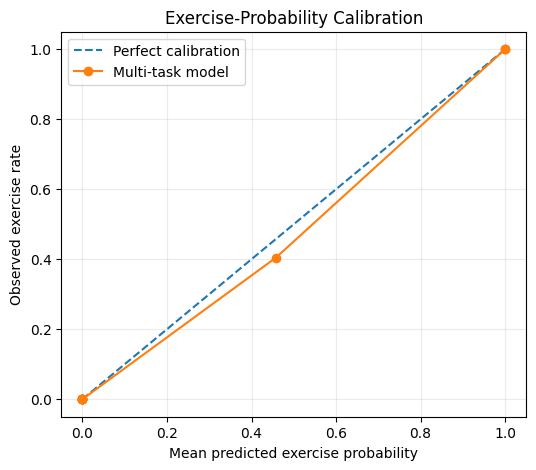

In [13]:
calibration = calibration_frame(
    test_results["exercise_now"],
    test_results["multitask_probability"],
    bins=10,
)
plt.figure(figsize=(6, 5))
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.plot(
    calibration["mean_predicted_probability"],
    calibration["observed_exercise_rate"],
    marker="o",
    label="Multi-task model",
)
plt.xlabel("Mean predicted exercise probability")
plt.ylabel("Observed exercise rate")
plt.title("Exercise-Probability Calibration")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# 8. Boundary-focused evaluation

The stopping decision depends on the comparison between immediate exercise value, $I$, and continuation value, $C$.

The signed margin is:

$$
M=\frac{I-C}{K}.
$$

Its sign identifies the decision region:

* $M>0$: exercise;
* $M<0$: continue;
* $M\approx0$: close to the exercise boundary.

For distance-based evaluation, the notebook uses:

$$
D=|M|.
$$

This measures proximity to the boundary without losing the signed margin used to identify the correct side.

Results are reported inside progressively wider bands around the boundary. The notebook also measures decision regret, which weights a wrong decision by the economic difference $|I-C|$. A mistake where exercise and continuation values are almost equal matters less than a mistake far from the boundary.

In [14]:
BANDS = (0.001, 0.005, 0.010)

classifier_boundary_metrics = boundary_band_metrics(
    test_results,
    probability_column="classifier_probability",
    bands=BANDS,
    threshold=CLASSIFIER_THRESHOLD,
).merge(
    boundary_decision_diagnostics(
        test_results,
        probability_column="classifier_probability",
        threshold=CLASSIFIER_THRESHOLD,
        bands=BANDS,
    ),
    on="boundary_band",
    validate="one_to_one",
)
classifier_boundary_metrics.insert(
    0,
    "model",
    "Exercise-only classifier",
)

multitask_boundary_metrics = boundary_band_metrics(
    test_results,
    probability_column="multitask_probability",
    bands=BANDS,
    threshold=MULTITASK_THRESHOLD,
    actual_price_column="normalized_american_price",
    predicted_price_column="predicted_normalized_american_price",
).merge(
    boundary_decision_diagnostics(
        test_results,
        probability_column="multitask_probability",
        threshold=MULTITASK_THRESHOLD,
        bands=BANDS,
    ),
    on="boundary_band",
    validate="one_to_one",
)
multitask_boundary_metrics.insert(
    0,
    "model",
    "Multi-task model",
)

boundary_comparison = pd.concat(
    [classifier_boundary_metrics, multitask_boundary_metrics],
    ignore_index=True,
)
boundary_comparison

,model,boundary_band,observations,accuracy,balanced_accuracy,precision,recall,f1,false_exercise_rate,missed_exercise_rate,price_mae,continuation_observations,exercise_observations,false_exercise_count,missed_exercise_count,decision_errors,mean_regret_all,mean_regret_when_wrong,maximum_regret,total_regret
0,Exercise-only classifier,0.001,59673.0,0.994537,0.991808,0.995666,0.997121,0.996393,0.013505,0.002879,NaN,14513,45160,196,130,326,0.000007,0.001218,0.013744,0.397192
1,Exercise-only classifier,0.005,73673.0,0.995575,0.995124,0.995666,0.997121,0.996393,0.006874,0.002879,NaN,28513,45160,196,130,326,0.000005,0.001218,0.013744,0.397192
2,Exercise-only classifier,0.010,80785.0,0.995965,0.995810,0.995666,0.997121,0.996393,0.005502,0.002879,NaN,35625,45160,196,130,326,0.000005,0.001218,0.013744,0.397192
3,Multi-task model,0.001,59673.0,0.992794,0.989675,0.994735,0.995748,0.995242,0.016399,0.004252,0.000053,14513,45160,238,192,430,0.000015,0.002121,0.077979,0.911827
4,Multi-task model,0.005,73673.0,0.994163,0.993701,0.994735,0.995748,0.995242,0.008347,0.004252,0.000099,28513,45160,238,192,430,0.000012,0.002121,0.077979,0.911827
5,Multi-task model,0.010,80785.0,0.994677,0.994534,0.994735,0.995748,0.995242,0.006681,0.004252,0.000120,35625,45160,238,192,430,0.000011,0.002121,0.077979,0.911827


### Boundary-classification result

The standalone classifier remains better inside every tested boundary band.

Across the test set it makes 326 decision errors, compared with 430 for the multi-task model. Its total exercise regret is 0.397, versus 0.912 for the multi-task model, and its average regret when wrong is also materially lower.

The difference is not just statistical. The standalone classifier makes fewer mistakes and its mistakes are less costly.

# 9. Comparison with the Notebook 05 price model

Notebook 05 selected a constrained floor-residual model trained only for pricing. It is the relevant benchmark for testing whether exercise supervision improves the price estimate.

Both models reconstruct the American price above the same financial floor:

$$
F=\max(V_E,I).
$$

The comparison therefore isolates the effect of adding the exercise-classification task to the shared network.

In [15]:
premium_checkpoint = load_checkpoint(
    PREMIUM_CHECKPOINT_PATH,
    map_location=DEVICE,
)
raw_config = premium_checkpoint["model_config"]
premium_model_config = PremiumMLPConfig(
    input_features=int(raw_config["input_features"]),
    hidden_sizes=tuple(raw_config["hidden_sizes"]),
    batch_norm_after=tuple(raw_config["batch_norm_after"]),
    output_activation=raw_config["output_activation"],
    residual_base=raw_config["residual_base"],
)
price_only_model = PremiumAmericanPutMLP(
    premium_model_config
).to(DEVICE)
price_only_model.load_state_dict(
    premium_checkpoint["model_state_dict"]
)
price_only_model.eval()

from src.data.torch_datasets import (
    AmericanOptionDataset,
    create_regression_loader,
)

price_only_dataset = AmericanOptionDataset(
    test_frame,
    scaler=feature_scaler,
    target_column="normalized_floor_residual",
)
price_only_loader = create_regression_loader(
    price_only_dataset,
    config=LOADER_CONFIG,
    shuffle=False,
)
price_only_residual = predict_regression_model(
    price_only_model,
    price_only_loader,
    device=DEVICE,
).rename(columns={"prediction": "price_only_residual"})
test_results = test_results.merge(
    price_only_residual,
    on="sample_id",
    validate="one_to_one",
)
test_results["price_only_normalized_price"] = (
    test_results["normalized_financial_floor"]
    + test_results["price_only_residual"]
)

price_metrics = pd.DataFrame(
    {
        "Price-only constrained residual": regression_metrics(
            test_results["normalized_american_price"],
            test_results["price_only_normalized_price"],
        ),
        "Multi-task constrained residual": regression_metrics(
            test_results["normalized_american_price"],
            test_results["predicted_normalized_american_price"],
        ),
    }
).T
price_metrics

,observations,mae,rmse,median_absolute_error,max_absolute_error,mean_error,r2,within_0.001,within_0.005,within_0.01,within_0.05
Price-only constrained residual,187811.0,0.000102,0.000213,0.000046,0.004641,-0.000014,0.999998,0.99286,1.000000,1.0,1.0
Multi-task constrained residual,187811.0,0.000199,0.000405,0.000073,0.007345,0.000014,0.999994,0.96767,0.999824,1.0,1.0


In [16]:
price_boundary_rows = []
for model_name, prediction_column in {
    "Price-only constrained residual": "price_only_normalized_price",
    "Multi-task constrained residual": "predicted_normalized_american_price",
}.items():
    for band in (0.001, 0.005, 0.010):
        subset = test_results.loc[
            test_results["boundary_distance_normalized"].abs() <= band
        ]
        metrics = regression_metrics(
            subset["normalized_american_price"],
            subset[prediction_column],
        )
        price_boundary_rows.append(
            {"model": model_name, "boundary_band": band, **metrics}
        )
price_boundary_comparison = pd.DataFrame(price_boundary_rows)
price_boundary_comparison

,model,boundary_band,observations,mae,rmse,median_absolute_error,max_absolute_error,mean_error,r2,within_0.001,within_0.005,within_0.01,within_0.05
0,Price-only constrained residual,0.001,59673.0,0.000052,0.000138,7.811330e-07,0.002193,0.000048,0.999999,0.998576,1.000000,1.0,1.0
1,Price-only constrained residual,0.005,73673.0,0.000073,0.000186,3.154947e-06,0.003286,0.000033,0.999999,0.994421,1.000000,1.0,1.0
2,Price-only constrained residual,0.010,80785.0,0.000079,0.000199,4.914584e-06,0.003586,0.000027,0.999999,0.993353,1.000000,1.0,1.0
3,Multi-task constrained residual,0.001,59673.0,0.000053,0.000161,3.258905e-07,0.004784,0.000045,0.999999,0.996162,1.000000,1.0,1.0
4,Multi-task constrained residual,0.005,73673.0,0.000099,0.000267,4.007626e-06,0.005228,0.000027,0.999998,0.984105,0.999986,1.0,1.0
5,Multi-task constrained residual,0.010,80785.0,0.000120,0.000316,6.912212e-06,0.005228,0.000022,0.999997,0.976642,0.999988,1.0,1.0


### Pricing result

The specialized Notebook 05 model remains clearly better.

Its full test MAE is 0.0102 price units, compared with 0.0199 for the multi-task model. Within the $D\leq0.01$ boundary region, the corresponding errors are approximately 0.0079 and 0.0120 price units.

Adding exercise supervision therefore worsens pricing by roughly 52% near the boundary instead of improving it.

# 10. Exercise-boundary reconstruction

For fixed values of maturity, rates, dividends, and volatility, the CRR engine and neural classifiers are evaluated across a dense moneyness grid. The boundary is the point where exercise probability crosses the selected classification threshold.

The neural boundary is not assumed to exist for every slice. Missing crossings are reported as missing coverage rather than silently extrapolated.

In [17]:
BOUNDARY_SLICES = [
    {
        "time_to_maturity": 0.25,
        "risk_free_rate": 0.03,
        "dividend_yield": 0.01,
        "volatility": 0.20,
    },
    {
        "time_to_maturity": 0.50,
        "risk_free_rate": 0.05,
        "dividend_yield": 0.01,
        "volatility": 0.25,
    },
    {
        "time_to_maturity": 1.00,
        "risk_free_rate": 0.07,
        "dividend_yield": 0.02,
        "volatility": 0.30,
    },
    {
        "time_to_maturity": 1.50,
        "risk_free_rate": 0.09,
        "dividend_yield": 0.03,
        "volatility": 0.40,
    },
]

boundary_rows = []
boundary_frames = []

for slice_id, specification in enumerate(
    BOUNDARY_SLICES
):
    frame = build_boundary_slice(
        **specification,
        feature_scaler=feature_scaler,
        feature_columns=FEATURE_COLUMNS,
        exercise_classifier=exercise_classifier,
        multitask_model=best_multitask_model,
        device=DEVICE,
    )
    frame["slice_id"] = slice_id
    boundary_frames.append(frame)

    actual = extract_label_boundary(
        frame["moneyness"],
        frame["exercise_now"],
    )
    classifier = extract_probability_boundary(
        frame["moneyness"],
        frame["classifier_probability"],
        threshold=CLASSIFIER_THRESHOLD,
    )
    multitask = extract_probability_boundary(
        frame["moneyness"],
        frame["multitask_probability"],
        threshold=MULTITASK_THRESHOLD,
    )

    boundary_rows.append(
        {
            "slice_id": slice_id,
            **specification,
            "crr_boundary": actual.boundary_moneyness,
            "classifier_boundary": classifier.boundary_moneyness,
            "multitask_boundary": multitask.boundary_moneyness,
        }
    )

boundary_curves = pd.DataFrame(boundary_rows)
boundary_grid = pd.concat(
    boundary_frames,
    ignore_index=True,
)
boundary_curves

,slice_id,time_to_maturity,risk_free_rate,dividend_yield,volatility,crr_boundary,classifier_boundary,multitask_boundary
0,0,0.25,0.03,0.01,0.20,0.838333,0.837977,0.838799
1,1,0.50,0.05,0.01,0.25,0.781667,0.780875,0.782392
2,2,1.00,0.07,0.02,0.30,0.705000,0.706704,0.706879
3,3,1.50,0.09,0.03,0.40,0.598333,0.599950,0.599971


In [18]:
classifier_boundary_error = boundary_location_error(
    boundary_curves["crr_boundary"],
    boundary_curves["classifier_boundary"],
)
multitask_boundary_error = boundary_location_error(
    boundary_curves["crr_boundary"],
    boundary_curves["multitask_boundary"],
)
pd.DataFrame(
    {
        "Exercise-only classifier": classifier_boundary_error,
        "Multi-task model": multitask_boundary_error,
    }
).T

,slices,valid_slices,coverage,boundary_mae,boundary_max_error
Exercise-only classifier,4.0,4.0,1.0,0.001117,0.001704
Multi-task model,4.0,4.0,1.0,0.001177,0.001879


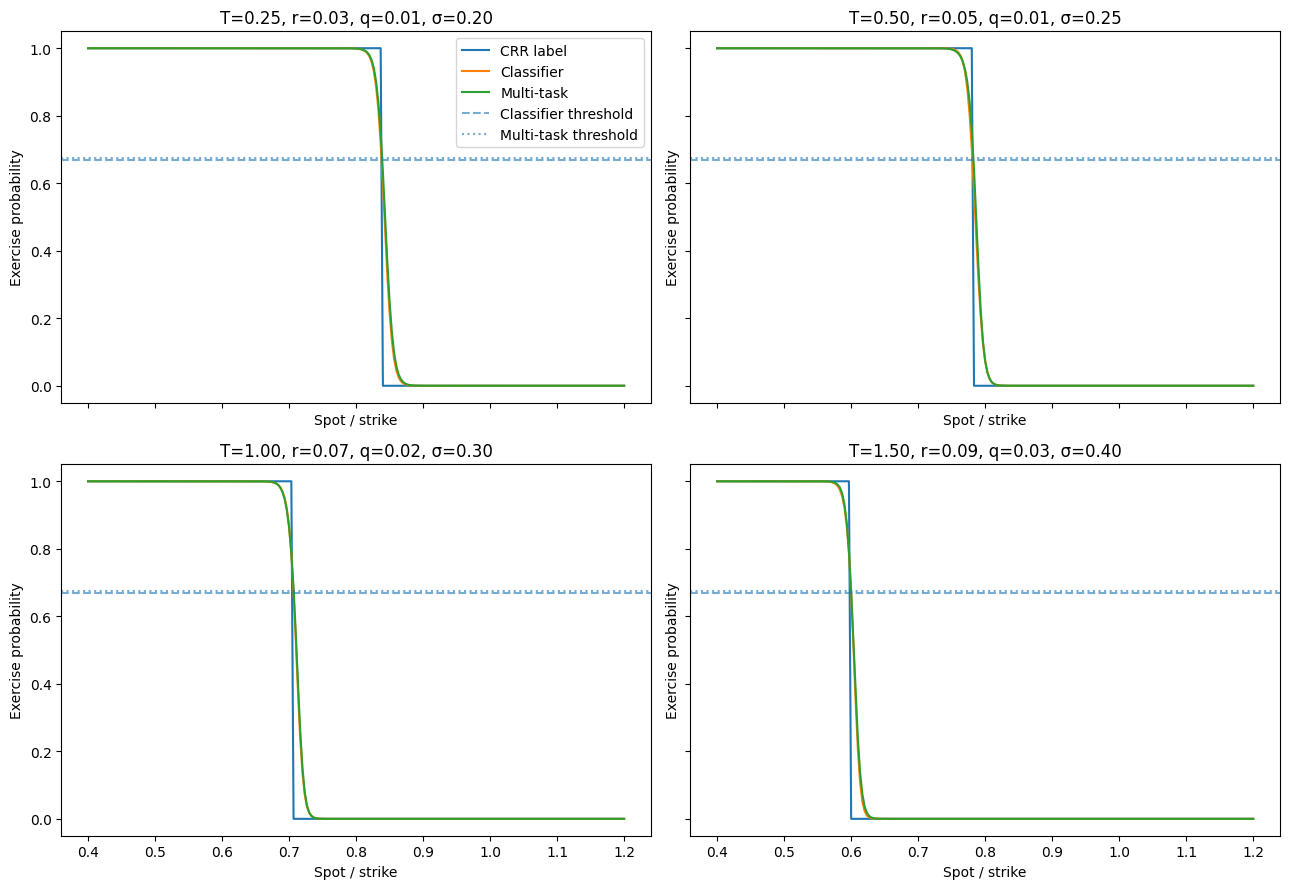

In [19]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(13, 9),
    sharex=True,
    sharey=True,
)

for axis, (slice_id, frame) in zip(
    axes.ravel(),
    boundary_grid.groupby("slice_id"),
):
    row = boundary_curves.loc[
        boundary_curves["slice_id"] == slice_id
    ].iloc[0]

    axis.plot(
        frame["moneyness"],
        frame["exercise_now"].astype(float),
        label="CRR label",
    )
    axis.plot(
        frame["moneyness"],
        frame["classifier_probability"],
        label="Classifier",
    )
    axis.plot(
        frame["moneyness"],
        frame["multitask_probability"],
        label="Multi-task",
    )
    axis.axhline(
        CLASSIFIER_THRESHOLD,
        linestyle="--",
        alpha=0.6,
        label="Classifier threshold",
    )
    axis.axhline(
        MULTITASK_THRESHOLD,
        linestyle=":",
        alpha=0.6,
        label="Multi-task threshold",
    )
    axis.set_title(
        f"T={row.time_to_maturity:.2f}, "
        f"r={row.risk_free_rate:.2f}, "
        f"q={row.dividend_yield:.2f}, "
        f"σ={row.volatility:.2f}"
    )
    axis.set_xlabel("Spot / strike")
    axis.set_ylabel("Exercise probability")

axes[0, 0].legend()
plt.tight_layout()
plt.show()

# 11. Boundary monotonicity diagnostics

The learned boundary should respond economically to the conditioning variables, but no monotonic relationship is hard-coded. The project therefore reports observed violations rather than assuming the network has learned a stable free-boundary surface.

The direction of the theoretical response can depend on which variables are held fixed. These checks are treated as diagnostics, not universal proofs.

In [20]:
BASE_BOUNDARY_SPEC = {
    "time_to_maturity": 0.75,
    "risk_free_rate": 0.05,
    "dividend_yield": 0.02,
    "volatility": 0.30,
}

MONOTONICITY_SWEEPS = {
    "time_to_maturity": {
        "values": np.linspace(0.10, 1.90, 11),
        "expected_direction": "decreasing",
    },
    "risk_free_rate": {
        "values": np.linspace(0.01, 0.10, 11),
        "expected_direction": "increasing",
    },
    "volatility": {
        "values": np.linspace(0.10, 0.75, 11),
        "expected_direction": "decreasing",
    },
}

boundary_sweep_rows = []

for parameter, sweep in MONOTONICITY_SWEEPS.items():
    for parameter_value in sweep["values"]:
        specification = dict(BASE_BOUNDARY_SPEC)
        specification[parameter] = float(
            parameter_value
        )

        frame = build_boundary_slice(
            **specification,
            feature_scaler=feature_scaler,
            feature_columns=FEATURE_COLUMNS,
            exercise_classifier=exercise_classifier,
            multitask_model=best_multitask_model,
            device=DEVICE,
            points=121,
        )

        actual = extract_label_boundary(
            frame["moneyness"],
            frame["exercise_now"],
        )
        classifier = extract_probability_boundary(
            frame["moneyness"],
            frame["classifier_probability"],
            threshold=CLASSIFIER_THRESHOLD,
        )
        multitask = extract_probability_boundary(
            frame["moneyness"],
            frame["multitask_probability"],
            threshold=MULTITASK_THRESHOLD,
        )

        boundary_sweep_rows.append(
            {
                "parameter": parameter,
                "parameter_value": float(
                    parameter_value
                ),
                "expected_direction": sweep[
                    "expected_direction"
                ],
                "crr_boundary": actual.boundary_moneyness,
                "classifier_boundary": (
                    classifier.boundary_moneyness
                ),
                "multitask_boundary": (
                    multitask.boundary_moneyness
                ),
            }
        )

boundary_sweep_results = pd.DataFrame(
    boundary_sweep_rows
)

monotonicity_rows = []

for parameter, sweep in MONOTONICITY_SWEEPS.items():
    parameter_frame = boundary_sweep_results.loc[
        boundary_sweep_results["parameter"]
        == parameter
    ]

    for model_name, boundary_column in {
        "CRR": "crr_boundary",
        "Exercise-only classifier": (
            "classifier_boundary"
        ),
        "Multi-task model": "multitask_boundary",
    }.items():
        monotonicity_rows.append(
            {
                "parameter": parameter,
                "model": model_name,
                "expected_direction": sweep[
                    "expected_direction"
                ],
                **boundary_monotonicity_report(
                    parameter_frame,
                    parameter_column=(
                        "parameter_value"
                    ),
                    boundary_column=boundary_column,
                    expected_direction=sweep[
                        "expected_direction"
                    ],
                ),
            }
        )

monotonicity_results = pd.DataFrame(
    monotonicity_rows
)
monotonicity_results

,parameter,model,expected_direction,comparisons,violations,violation_rate
0,time_to_maturity,CRR,decreasing,10.0,0.0,0.0
1,time_to_maturity,Exercise-only classifier,decreasing,10.0,0.0,0.0
2,time_to_maturity,Multi-task model,decreasing,10.0,0.0,0.0
3,risk_free_rate,CRR,increasing,10.0,0.0,0.0
4,risk_free_rate,Exercise-only classifier,increasing,10.0,0.0,0.0
5,risk_free_rate,Multi-task model,increasing,10.0,0.0,0.0
6,volatility,CRR,decreasing,8.0,0.0,0.0
7,volatility,Exercise-only classifier,decreasing,8.0,0.0,0.0
8,volatility,Multi-task model,decreasing,8.0,0.0,0.0


### Boundary reconstruction

Both neural models track the CRR boundary closely across the selected slices.

The standalone classifier has a boundary-location MAE of 0.00112 in moneyness, slightly better than 0.00118 for the multi-task model. In the one-factor sweeps, both models also reproduce the expected boundary direction for maturity, interest rates, and volatility without monotonicity violations.

The learned boundary is therefore economically coherent, but the multi-task representation does not improve its location.

# 12. Out-of-domain evaluation and inference speed

The four OOD datasets test parameter regimes that were excluded from training and model selection.

Classification and pricing are evaluated separately:

* the exercise-only classifier is compared with the multi-task classification head;
* the Notebook 05 price-only model is compared with the multi-task regression head.

This separation matters because the multi-task model may help one objective while damaging the other.

The final table also reports raw forward-pass speed. It measures neural inference on an in-memory feature tensor and excludes file loading, feature scaling, data transfer, and output processing.

In [21]:
ood_classification_rows = []
ood_pricing_rows = []

for ood_name, path in OOD_PATHS.items():
    frame = read_parquet_components(
        [path],
        columns=MODEL_COLUMNS,
        split=None,
    )
    frame["normalized_intrinsic_value"] = (
        frame["intrinsic_value"]
        / frame["strike"]
    )
    frame["normalized_financial_floor"] = np.maximum(
        frame["normalized_european_price"],
        frame["normalized_intrinsic_value"],
    )
    frame["normalized_floor_residual"] = (
        frame["normalized_american_price"]
        - frame["normalized_financial_floor"]
    ).clip(lower=0.0)
    frame["signed_boundary_margin"] = (
        frame["intrinsic_value"]
        - frame["continuation_value"]
    ) / frame["strike"]
    frame["boundary_distance_normalized"] = (
        frame["signed_boundary_margin"].abs()
    )

    _, multitask_loader = make_multitask_loader(
        frame,
        shuffle=False,
    )

    classifier_predictions = predict_exercise_classifier(
        exercise_classifier,
        multitask_loader,
        device=DEVICE,
    ).rename(
        columns={
            "exercise_probability": (
                "classifier_probability"
            )
        }
    )
    multitask_predictions = predict_multitask_model(
        best_multitask_model,
        multitask_loader,
        device=DEVICE,
        classification_threshold=MULTITASK_THRESHOLD,
    ).rename(
        columns={
            "exercise_probability": (
                "multitask_probability"
            )
        }
    )

    price_only_dataset = AmericanOptionDataset(
        frame,
        scaler=feature_scaler,
        target_column="normalized_floor_residual",
    )
    price_only_loader = create_regression_loader(
        price_only_dataset,
        config=LOADER_CONFIG,
        shuffle=False,
    )
    price_only_predictions = predict_regression_model(
        price_only_model,
        price_only_loader,
        device=DEVICE,
    ).rename(
        columns={
            "prediction": "price_only_residual"
        }
    )

    result = (
        frame.merge(
            classifier_predictions[
                [
                    "sample_id",
                    "classifier_probability",
                ]
            ],
            on="sample_id",
            validate="one_to_one",
        )
        .merge(
            multitask_predictions[
                [
                    "sample_id",
                    "multitask_probability",
                    "predicted_normalized_american_price",
                ]
            ],
            on="sample_id",
            validate="one_to_one",
        )
        .merge(
            price_only_predictions,
            on="sample_id",
            validate="one_to_one",
        )
    )
    result["price_only_normalized_price"] = (
        result["normalized_financial_floor"]
        + result["price_only_residual"]
    )

    for model_name, probability_column, threshold in (
        (
            "Exercise-only classifier",
            "classifier_probability",
            CLASSIFIER_THRESHOLD,
        ),
        (
            "Multi-task model",
            "multitask_probability",
            MULTITASK_THRESHOLD,
        ),
    ):
        ood_classification_rows.append(
            {
                "ood_set": ood_name,
                "model": model_name,
                **binary_classification_metrics(
                    result["exercise_now"],
                    result[probability_column],
                    threshold=threshold,
                ),
            }
        )

    for model_name, prediction_column in {
        "Price-only constrained residual": (
            "price_only_normalized_price"
        ),
        "Multi-task constrained residual": (
            "predicted_normalized_american_price"
        ),
    }.items():
        ood_pricing_rows.append(
            {
                "ood_set": ood_name,
                "model": model_name,
                **regression_metrics(
                    result[
                        "normalized_american_price"
                    ],
                    result[prediction_column],
                ),
            }
        )

ood_classification_results = pd.DataFrame(
    ood_classification_rows
)
ood_pricing_results = pd.DataFrame(
    ood_pricing_rows
)

# Backward-compatible combined export.
ood_results = pd.concat(
    [
        ood_classification_results.assign(
            task="classification"
        ),
        ood_pricing_results.assign(
            task="pricing"
        ),
    ],
    ignore_index=True,
    sort=False,
)

display(ood_classification_results)
display(ood_pricing_results)

benchmark_size = min(100_000, len(test_frame))
benchmark_values = feature_scaler.transform(
    test_frame.iloc[:benchmark_size]
    .loc[:, FEATURE_COLUMNS]
    .to_numpy(dtype=np.float64)
).astype(np.float32)
benchmark_features = torch.from_numpy(
    benchmark_values
).to(DEVICE)

inference_results = pd.DataFrame(
    [
        {
            "model": model_name,
            **benchmark_forward_pass(
                model,
                benchmark_features,
                device=DEVICE,
                repeats=20,
                warmup=5,
            ),
        }
        for model_name, model in {
            "Exercise-only classifier": (
                exercise_classifier
            ),
            "Price-only constrained residual": (
                price_only_model
            ),
            "Multi-task model": (
                best_multitask_model
            ),
        }.items()
    ]
).set_index("model")

inference_results

,ood_set,model,observations,positive_rate,threshold,accuracy,balanced_accuracy,precision,recall,f1,brier_score,roc_auc,pr_auc
0,high_volatility,Exercise-only classifier,50000.0,0.00244,0.670,0.99820,0.982744,0.578431,0.967213,0.723926,0.001715,0.999554,0.827105
1,high_volatility,Multi-task model,50000.0,0.00244,0.675,0.99868,0.958455,0.666667,0.918033,0.772414,0.001440,0.999722,0.914294
2,extreme_moneyness,Exercise-only classifier,50000.0,0.36468,0.670,0.98390,0.980648,0.986980,0.968630,0.977719,0.010650,0.999135,0.998471
3,extreme_moneyness,Multi-task model,50000.0,0.36468,0.675,0.98658,0.984264,0.987347,0.975705,0.981491,0.009756,0.999230,0.998641
4,long_maturity,Exercise-only classifier,50000.0,0.06652,0.670,0.92898,0.940738,0.482885,0.954299,0.641277,0.067376,0.987063,0.877858
5,long_maturity,Multi-task model,50000.0,0.06652,0.675,0.95814,0.972832,0.615212,0.989778,0.758788,0.041245,0.997333,0.971661
6,rate_dividend,Exercise-only classifier,50000.0,0.16920,0.670,0.98616,0.984517,0.938969,0.982033,0.960018,0.012263,0.998935,0.994774
7,rate_dividend,Multi-task model,50000.0,0.16920,0.675,0.98272,0.979105,0.927799,0.973641,0.950167,0.015343,0.998632,0.993856


,ood_set,model,observations,mae,rmse,median_absolute_error,max_absolute_error,mean_error,r2,within_0.001,within_0.005,within_0.01,within_0.05
0,high_volatility,Price-only constrained residual,50000.0,0.000568,0.001110,0.000237,0.011833,0.000383,0.999940,0.84976,0.99084,0.99984,1.00000
1,high_volatility,Multi-task constrained residual,50000.0,0.007619,0.033913,0.001252,1.593428,0.005014,0.944203,0.45168,0.77822,0.87476,0.97156
2,extreme_moneyness,Price-only constrained residual,50000.0,0.000118,0.000378,0.000004,0.011095,-0.000006,0.999998,0.98090,0.99924,0.99996,1.00000
3,extreme_moneyness,Multi-task constrained residual,50000.0,0.000477,0.001960,0.000004,0.060666,-0.000036,0.999958,0.89360,0.98046,0.99340,0.99998
4,long_maturity,Price-only constrained residual,50000.0,0.003432,0.007965,0.000597,0.083836,-0.000913,0.997521,0.57118,0.80696,0.90328,0.99608
5,long_maturity,Multi-task constrained residual,50000.0,0.010425,0.018540,0.003246,0.114158,-0.009101,0.986566,0.35974,0.56130,0.67740,0.96562
6,rate_dividend,Price-only constrained residual,50000.0,0.002961,0.006051,0.000551,0.048240,-0.002685,0.998336,0.57702,0.80782,0.90796,1.00000
7,rate_dividend,Multi-task constrained residual,50000.0,0.004213,0.014501,0.000893,0.397845,0.002829,0.990445,0.52080,0.82674,0.91384,0.98812


,observations,median_seconds,observations_per_second
model,,,
Exercise-only classifier,100000,0.181505,550947.947122
Price-only constrained residual,100000,0.200708,498235.622977
Multi-task model,100000,0.214673,465825.742432


### Out-of-domain result

The multi-task classifier performs better in high-volatility, extreme-moneyness, and long-maturity regimes, but worse under the elevated rate-and-dividend shift.

That classification improvement does not carry over to pricing. The specialized price model has lower MAE in all four OOD sets.

The largest failure is high volatility, where the multi-task model has an average error of approximately 0.762 price units and a maximum error of approximately 159 price units. Long maturity also remains difficult, with MAE increasing from about 0.343 for the price-only model to 1.043 for the multi-task model.

Raw CPU throughput is similar for all three networks, at roughly 458,000–499,000 observations per second. The multi-task model therefore provides no material inference-speed advantage.

# 13. Formal H4 decision

H4 tests whether joint learning improves the exercise-boundary problem without damaging pricing.

The multi-task model must satisfy both conditions inside the $D\leq0.01$ boundary band:

1. classification F1 may decline by no more than 0.001 relative to the standalone classifier;
2. pricing MAE must improve by at least 1% relative to the specialized Notebook 05 price model.

The first condition is a non-inferiority test. The standalone classifier is already close to perfect, so requiring a large absolute F1 improvement would not be realistic.

H4 is supported only if both conditions are met.

In [22]:
classifier_band_f1 = float(
    classifier_boundary_metrics.loc[
        np.isclose(
            classifier_boundary_metrics[
                "boundary_band"
            ],
            0.01,
        ),
        "f1",
    ].iloc[0]
)
multitask_band_f1 = float(
    multitask_boundary_metrics.loc[
        np.isclose(
            multitask_boundary_metrics[
                "boundary_band"
            ],
            0.01,
        ),
        "f1",
    ].iloc[0]
)
price_only_band_mae = float(
    price_boundary_comparison.loc[
        (
            price_boundary_comparison["model"]
            == "Price-only constrained residual"
        )
        & np.isclose(
            price_boundary_comparison[
                "boundary_band"
            ],
            0.01,
        ),
        "mae",
    ].iloc[0]
)
multitask_band_mae = float(
    price_boundary_comparison.loc[
        (
            price_boundary_comparison["model"]
            == "Multi-task constrained residual"
        )
        & np.isclose(
            price_boundary_comparison[
                "boundary_band"
            ],
            0.01,
        ),
        "mae",
    ].iloc[0]
)

MAXIMUM_F1_DEGRADATION = 0.001
MINIMUM_BOUNDARY_MAE_IMPROVEMENT = 0.01

boundary_f1_change = (
    multitask_band_f1 - classifier_band_f1
)
boundary_mae_relative_improvement = (
    price_only_band_mae - multitask_band_mae
) / max(
    price_only_band_mae,
    np.finfo(np.float64).eps,
)

classification_noninferior = (
    boundary_f1_change
    >= -MAXIMUM_F1_DEGRADATION
)
pricing_improved = (
    boundary_mae_relative_improvement
    >= MINIMUM_BOUNDARY_MAE_IMPROVEMENT
)

if classification_noninferior and pricing_improved:
    h4_status = "supported"
    h4_rationale = (
        "The multi-task model preserves boundary classification "
        "within the predefined tolerance and improves boundary pricing."
    )
elif (
    boundary_f1_change > 0.0
    or boundary_mae_relative_improvement > 0.0
):
    h4_status = "partially supported"
    h4_rationale = (
        "The multi-task model improves one boundary objective, "
        "but does not satisfy the joint decision rule."
    )
else:
    h4_status = "not supported"
    h4_rationale = (
        "The multi-task model improves neither boundary F1 nor "
        "boundary pricing relative to the specialized models."
    )

h4_decision = H4Decision(
    hypothesis="H4 — Multi-task exercise learning",
    decision=h4_status,
    rationale=h4_rationale,
    evidence={
        "classifier_boundary_f1": classifier_band_f1,
        "multitask_boundary_f1": multitask_band_f1,
        "boundary_f1_change": float(
            boundary_f1_change
        ),
        "maximum_allowed_f1_degradation": float(
            MAXIMUM_F1_DEGRADATION
        ),
        "classification_noninferior": float(
            classification_noninferior
        ),
        "price_only_boundary_mae": price_only_band_mae,
        "multitask_boundary_mae": multitask_band_mae,
        "boundary_mae_relative_improvement": float(
            boundary_mae_relative_improvement
        ),
        "required_boundary_mae_improvement": float(
            MINIMUM_BOUNDARY_MAE_IMPROVEMENT
        ),
    },
)
h4_decision.to_dict()

{'hypothesis': 'H4 — Multi-task exercise learning',
 'decision': 'not supported',
 'rationale': 'The multi-task model improves neither boundary F1 nor boundary pricing relative to the specialized models.',
 'evidence': {'classifier_boundary_f1': 0.996393246741752,
  'multitask_boundary_f1': 0.9952415731580462,
  'boundary_f1_change': -0.0011516735837058256,
  'maximum_allowed_f1_degradation': 0.001,
  'classification_noninferior': 0.0,
  'price_only_boundary_mae': 7.883114408639497e-05,
  'multitask_boundary_mae': 0.00011950799866084253,
  'boundary_mae_relative_improvement': -0.5159997998997423,
  'required_boundary_mae_improvement': 0.01}}

### H4 result

H4 is not supported.

Boundary F1 falls from 0.99639 to 0.99524, a decline of 0.00115. This narrowly exceeds the allowed non-inferiority tolerance of 0.001.

More importantly, boundary pricing MAE increases by approximately 52%. The multi-task model therefore improves neither of the two objectives required by H4.


# 14. Save artifacts

The selected model, validation selection, test metrics, boundary curves, and formal hypothesis decision are saved for the final consolidated evaluation in Notebook 09.

In [23]:
classification_comparison.to_csv(
    MULTITASK_ARTIFACT_DIR / "classification_metrics.csv"
)
boundary_comparison.to_csv(
    MULTITASK_ARTIFACT_DIR / "boundary_metrics.csv",
    index=False,
)
price_metrics.to_csv(
    MULTITASK_ARTIFACT_DIR / "price_metrics.csv"
)
price_boundary_comparison.to_csv(
    MULTITASK_ARTIFACT_DIR / "boundary_price_metrics.csv",
    index=False,
)
boundary_curves.to_parquet(
    MULTITASK_ARTIFACT_DIR / "boundary_curves.parquet",
    index=False,
)
boundary_sweep_results.to_csv(
    MULTITASK_ARTIFACT_DIR / "boundary_parameter_sweeps.csv",
    index=False,
)
monotonicity_results.to_csv(
    MULTITASK_ARTIFACT_DIR / "boundary_monotonicity.csv",
    index=False,
)
ood_classification_results.to_csv(
    MULTITASK_ARTIFACT_DIR / "ood_classification_metrics.csv",
    index=False,
)
ood_pricing_results.to_csv(
    MULTITASK_ARTIFACT_DIR / "ood_pricing_metrics.csv",
    index=False,
)
ood_results.to_csv(
    MULTITASK_ARTIFACT_DIR / "ood_results.csv",
    index=False,
)
model_training_summary.to_csv(
    MULTITASK_ARTIFACT_DIR / "model_training_summary.csv"
)
inference_results.to_csv(
    MULTITASK_ARTIFACT_DIR / "inference_benchmark.csv"
)
save_json(
    h4_decision.to_dict(),
    MULTITASK_ARTIFACT_DIR / "hypothesis_decision.json",
)
save_json(
    {
        "selected_candidate": best_candidate_name,
        "selection_f1_tolerance": float(
            F1_SELECTION_TOLERANCE
        ),
        "exercise_lambda": float(
            best_candidate["exercise_lambda"]
        ),
        "classifier_threshold": float(
            CLASSIFIER_THRESHOLD
        ),
        "multitask_threshold": float(
            MULTITASK_THRESHOLD
        ),
        "positive_class_weight": float(
            positive_class_weight
        ),
        "fast_dev_mode": FAST_DEV_MODE,
        "model_config": (
            best_candidate["checkpoint"][
                "model_config"
            ]
        ),
        "dependencies": canonicalize_json_value(
            current_external_dependencies
        ),
    },
    MULTITASK_ARTIFACT_DIR / "evaluation_summary.json",
)
print(f"Artifacts saved to: {MULTITASK_ARTIFACT_DIR}")

Artifacts saved to: D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and_ML_upskill_program\Deep_Learning\deep_learning_american_option_pricing\artifacts\multitask_model


# 15. Interpretation framework

The final interpretation should distinguish three questions:

1. **Is the exercise decision learnable?**  
   This is answered by the exercise-only classifier.

2. **Does joint learning improve boundary decisions?**  
   This is answered by boundary-band F1 and reconstructed boundary error.

3. **Does classification supervision improve pricing where it matters most?**  
   This is answered by price MAE near the exercise boundary relative to the Step 5 price-only constrained model.

A strong aggregate price result does not compensate for systematic stopping errors. Conversely, improved classification is not sufficient if joint training materially damages pricing accuracy.

# 16. Limitations

- Exercise labels are produced by a finite CRR tree and inherit its discretization error.
- Root-node classification does not represent the complete future stopping policy along every simulated path.
- Boundary class imbalance can make threshold-dependent metrics unstable.
- The selected probability threshold is validation-specific and may shift out of domain.
- The reconstructed boundary uses fixed parameter slices and does not prove global monotonicity.
- Constant volatility and continuous dividends remain material simplifications.
- Multi-task gains may depend on the chosen loss weight and shared-backbone capacity.

# 17. References used in this notebook

Cox, J. C., Ross, S. A., & Rubinstein, M. (1979). Option pricing: A simplified approach. *Journal of Financial Economics, 7*(3), 229–263.

Longstaff, F. A., & Schwartz, E. S. (2001). Valuing American options by simulation: A simple least-squares approach. *Review of Financial Studies, 14*(1), 113–147.

Pu, V. R. H. (2021). *Pricing options using deep neural networks from a practical perspective* [Master’s thesis, Imperial College London].

Zouaoui, H., & Naas, M.-N. (2023). Option pricing using deep learning approach based on LSTM-GRU neural networks. *Data Science in Finance and Economics, 3*(3), 267–284.

# 18. Conclusion and handoff to Notebook 07

Notebook 06 tested whether one shared neural representation could handle two related tasks at the same time:

* estimate the American put price;
* decide whether immediate exercise is optimal.

The idea was reasonable. Pricing and exercise are based on the same option parameters, and both are closely linked to the continuation value. A shared model might therefore learn a better representation of the exercise boundary than two independent networks.

The results do not support that expectation.

## The exercise decision is learnable

The standalone exercise classifier performs extremely well.

On the held-out test set it achieves:

* F1 of 0.9964;
* balanced accuracy of 0.9979;
* PR-AUC of 0.99995;
* only 430 incorrect decisions out of 187,811 observations.

Its selected threshold is 0.67 rather than 0.50 because the model was trained with a positive-class weight. The threshold was selected using validation data only.

The model also reconstructs the CRR exercise boundary closely. Its average boundary-location error across the reference slices is approximately 0.0011 in moneyness.

This means that the static root-node exercise decision can be learned very accurately from the five pricing inputs.

## Joint learning does not improve the result

Three multi-task candidates were trained with different exercise-loss weights.

The final candidate used $\lambda=1.0$. It was selected because its boundary F1 was within 0.001 of the best candidate and it had the lowest pricing error among the models meeting that classification tolerance.

Even with that balanced selection rule, the multi-task model does not outperform the specialized models.

Its test F1 is 0.9952, slightly below the standalone classifier. It also makes more boundary errors and produces more than twice the total exercise regret.

The pricing result is weaker more clearly. The specialized Notebook 05 model has an average test error of approximately 0.0102 price units, while the multi-task model reaches approximately 0.0199.

Near the exercise boundary, where joint supervision was expected to help most, pricing MAE increases by approximately 52%.

The shared representation therefore creates interference rather than useful transfer. The two losses compete for the same limited network capacity, and the classification objective moves the representation away from the most accurate pricing solution.

## Out-of-domain results are mixed

The multi-task classification head improves F1 in three of the four OOD regimes, including a meaningful gain for long maturities.

That does not make the overall model preferable.

The separate Notebook 05 pricing model remains more accurate in every OOD regime. The multi-task model is especially unstable under high volatility, where a small number of large errors produce a maximum miss of approximately 159 price units.

The specialized models also have comparable or better inference speed. Combining the tasks therefore does not produce an operational advantage that would compensate for the weaker pricing result.

## Status of the project hypotheses

The project has now tested four progressively more structured ideas.

**H1 — Direct neural pricing:** supported.
A standard MLP materially outperforms the European Black–Scholes proxy for in-domain American put pricing.

**H2 — Early-exercise-premium decomposition:** supported.
Learning only the American component produces a major improvement over direct price prediction.

**H3 — Financially constrained residual learning:** supported.
Building the model above the financial floor eliminates pricing violations and further improves accuracy.

**H4 — Multi-task exercise learning:** not supported.
A shared pricing-and-classification model does not improve exercise F1 and materially worsens pricing, including near the exercise boundary.

The practical conclusion is straightforward:

```text
Use the constrained residual model for pricing.
Use the standalone classifier for the exercise decision.
Do not combine them merely because the tasks are related.
```

This is still a useful result. Multi-task learning is not automatically better, and a negative ablation prevents the project from carrying unnecessary complexity into the final design.

## Handoff to Notebook 07

Notebooks 04–06 are static surrogate models. They learn the root-node price or root-node exercise decision directly from contract parameters.

Notebook 07 moves to a different problem.

The Longstaff–Schwartz method simulates future price paths and works backward through time. At each exercise date it estimates the continuation value from the future discounted cash flows of paths that are still alive.

The next notebook will compare:

* the classical Longstaff–Schwartz regression approach;
* a neural continuation-value model;
* pricing accuracy against the CRR benchmark;
* exercise behaviour along simulated paths;
* computational cost and stability.

The project now has strong specialized models for static pricing and root exercise classification. Notebook 07 tests whether neural networks also add value inside a path-dependent backward-induction algorithm.

## Canonical final-result exports

This cell publishes the normalized artifacts consumed by Notebook 09 and tracked through DVC. Existing research outputs above remain unchanged.


In [24]:
# Canonical Notebook 06 exports for Notebook 09 and DVC.

multitask_prediction_columns = [
    column
    for column in (
        "sample_id",
        "split",
        "moneyness",
        "log_moneyness",
        "time_to_maturity",
        "risk_free_rate",
        "dividend_yield",
        "volatility",
        "exercise_now",
        "signed_boundary_margin",
        "boundary_distance_normalized",
        "normalized_european_price",
        "normalized_intrinsic_value",
        "normalized_financial_floor",
        "normalized_american_price",
        "classifier_probability",
        "multitask_probability",
        "predicted_residual",
        "predicted_normalized_american_price",
        "price_only_residual",
        "price_only_normalized_price",
    )
    if column in test_results.columns
]
multitask_test_predictions_export = test_results.loc[
    :,
    multitask_prediction_columns,
].copy()
multitask_test_predictions_export.to_parquet(
    MULTITASK_ARTIFACT_DIR / "test_predictions.parquet",
    index=False,
)

boundary_location_comparison = pd.DataFrame(
    {
        "Exercise-only classifier": classifier_boundary_error,
        "Multi-task model": multitask_boundary_error,
    }
).T
boundary_location_comparison.index.name = "model"
boundary_location_comparison.to_csv(
    MULTITASK_ARTIFACT_DIR
    / "boundary_location_metrics.csv",
)

boundary_sweep_results.to_csv(
    MULTITASK_ARTIFACT_DIR
    / "boundary_parameter_sweeps.csv",
    index=False,
)
monotonicity_results.to_csv(
    MULTITASK_ARTIFACT_DIR
    / "boundary_monotonicity.csv",
    index=False,
)

canonical_multitask_checkpoint = (
    MULTITASK_ARTIFACT_DIR / "best_multitask_pricer.pt"
)
shutil.copy2(
    candidate_checkpoint_paths[best_candidate_name],
    canonical_multitask_checkpoint,
)

multitask_financial_consistency = pd.DataFrame(
    [
        {
            "model": "Price-only constrained residual",
            "negative_price_count": int(
                (
                    test_results[
                        "price_only_normalized_price"
                    ]
                    < 0.0
                ).sum()
            ),
            "below_financial_floor_count": int(
                (
                    test_results[
                        "price_only_normalized_price"
                    ]
                    < test_results[
                        "normalized_financial_floor"
                    ]
                ).sum()
            ),
        },
        {
            "model": "Multi-task constrained residual",
            "negative_price_count": int(
                (
                    test_results[
                        "predicted_normalized_american_price"
                    ]
                    < 0.0
                ).sum()
            ),
            "below_financial_floor_count": int(
                (
                    test_results[
                        "predicted_normalized_american_price"
                    ]
                    < test_results[
                        "normalized_financial_floor"
                    ]
                ).sum()
            ),
        },
    ]
)
multitask_financial_consistency[
    "observations"
] = len(test_results)
multitask_financial_consistency[
    "negative_price_rate"
] = (
    multitask_financial_consistency[
        "negative_price_count"
    ]
    / len(test_results)
)
multitask_financial_consistency[
    "below_financial_floor_rate"
] = (
    multitask_financial_consistency[
        "below_financial_floor_count"
    ]
    / len(test_results)
)
multitask_financial_consistency.to_csv(
    MULTITASK_ARTIFACT_DIR
    / "financial_consistency.csv",
    index=False,
)

model_training_summary.to_csv(
    MULTITASK_ARTIFACT_DIR
    / "model_training_summary.csv"
)
inference_results.to_csv(
    MULTITASK_ARTIFACT_DIR
    / "inference_benchmark.csv"
)

multitask_final_metrics = {
    "schema_version": 1,
    "status": "complete",
    "notebook": "06_exercise_boundary_analysis",
    "training_profile": TRAINING_PROFILE,
    "selected_candidate": best_candidate_name,
    "selection_f1_tolerance": float(
        F1_SELECTION_TOLERANCE
    ),
    "checkpoint": canonical_multitask_checkpoint.name,
    "dependencies": current_external_dependencies,
    "thresholds": {
        "exercise_classifier": float(
            CLASSIFIER_THRESHOLD
        ),
        "multitask": float(MULTITASK_THRESHOLD),
    },
    "model_training": (
        model_training_summary
        .reset_index()
        .to_dict(orient="records")
    ),
    "classification": (
        classification_comparison
        .reset_index()
        .rename(columns={"index": "model"})
        .to_dict(orient="records")
    ),
    "pricing": (
        price_metrics
        .reset_index()
        .rename(columns={"index": "model"})
        .to_dict(orient="records")
    ),
    "boundary_bands": (
        boundary_comparison.to_dict(
            orient="records"
        )
    ),
    "boundary_pricing": (
        price_boundary_comparison.to_dict(
            orient="records"
        )
    ),
    "boundary_location": (
        boundary_location_comparison
        .reset_index()
        .to_dict(orient="records")
    ),
    "boundary_parameter_sweeps": (
        boundary_sweep_results.to_dict(
            orient="records"
        )
    ),
    "boundary_monotonicity": (
        monotonicity_results.to_dict(
            orient="records"
        )
    ),
    "financial_consistency": (
        multitask_financial_consistency.to_dict(
            orient="records"
        )
    ),
    "ood_classification": (
        ood_classification_results.to_dict(
            orient="records"
        )
    ),
    "ood_pricing": (
        ood_pricing_results.to_dict(
            orient="records"
        )
    ),
    "ood": ood_results.to_dict(
        orient="records"
    ),
    "inference": (
        inference_results
        .reset_index()
        .to_dict(orient="records")
    ),
    "hypothesis": h4_decision.to_dict(),
}
_write_export_json(
    MULTITASK_ARTIFACT_DIR / "final_metrics.json",
    multitask_final_metrics,
)

print("Canonical Notebook 06 exports saved.")

Canonical Notebook 06 exports saved.
